# Ablation study — Section 5.6

Four figures:

| Figure | Content |
|---|---|
| **1** `fig1_landing` | landing accuracy relative to the baseline (per-cell difference maps), degradation vs jump distance, stratified mean |
| **2** `fig2_bounce` | bounce at touchdown relative to the baseline (difference maps), stratified mean |
| **3** `fig3_liftoff` | lift-off state tracking as error / baseline error, plus a difference map per component (position, linear velocity, orientation, angular velocity) |
| **4** `fig4_landing_per_target` | landing error per target on the grid with the failed targets marked, paired with the difference maps of Figure 1 |

Targets are sampled randomly and independently per run, so nothing can be paired sample by sample.
Everything is compared over a shared grid partition of the command space: cell by cell, with
aggregates stratified over cells (each region weighted equally), cluster-bootstrap confidence
intervals over cells, and Wilcoxon signed-rank over cells with Holm correction.

## 1. Setup

In [1]:
import os
import os.path as osp
import warnings
from itertools import product

import numpy as np
import pandas as pd
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 200)
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 500, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.30, "axes.axisbelow": True,
    "legend.frameon": False,
})

robot = "go1"
cwd = os.getcwd()
data_path = osp.abspath(osp.join(cwd, f"../../../../logs/rsl_rl/unitree_{robot}_jump/ablation"))
# data_path = "/absolute/path/to/ablation"      # <-- override if the relative path is wrong
print("data path :", data_path, "| exists:", osp.isdir(data_path))

FIG_DIR = osp.join(data_path, "figures_ablation")
os.makedirs(FIG_DIR, exist_ok=True)

BASELINE = "baseline"
EXPERIMENTS = {
    "baseline":                    "Baseline",
    "no_uarm":                     "w/o UARM",
    "no_liftoof_disc_penalty":     "w/o LO",
    "no_bounce_angular_touchdown": "w/o TD",
}
COLORS = {
    "baseline":                    "#2c3e50",
    "no_uarm":                     "#c0392b",
    "no_liftoof_disc_penalty":     "#2980b9",
    "no_bounce_angular_touchdown": "#e67e22",
}
LO_MAP_POLICY = "no_liftoof_disc_penalty"     # policy shown in the Figure 3 maps

PEN_CAP  = 0.50      # [m] failed jumps are censored here so accuracy is not selection-biased
GRID_NX, GRID_NY = 20, 15
MIN_PER_CELL = 5
SAVE_FIGS = True


def savefig(fig, name):
    if SAVE_FIGS:
        for ext in ("pdf", "png"):
            fig.savefig(osp.join(FIG_DIR, f"{name}.{ext}"), bbox_inches="tight")

data path : /home/riccardo/Documents/guided-rl-jump/logs/rsl_rl/unitree_go1_jump/ablation | exists: True


## 2. Loading

Two things that affect the numbers rather than just the plots:

* **Landing error is censored at `PEN_CAP` for failed jumps.** Averaging only over successful jumps
  is selection-biased: a policy that fails on the hard targets looks accurate on the ones that
  survive.
* **Bounce sentinel.** Section 4.3 sets the bounce cost to a high default when no valid touchdown is
  detected. If that value is present in `bounce_err.bin` it is a failure flag, not a distance, and it
  would inflate the bounce mean. The loader detects it and reports those samples as invalid
  touchdowns instead.

In [2]:
def _np(x):
    return np.asarray(x.detach().cpu().numpy() if hasattr(x, "detach") else x)


def _load(path):
    if not osp.isfile(path):
        return None
    o = joblib.load(path)
    return [_np(a) for a in o] if isinstance(o, (list, tuple)) else _np(o)


def _as_error(raw):
    # accepts an error array, or a [desired, actual] pair
    if raw is None:
        return None
    if (isinstance(raw, (list, tuple)) and len(raw) == 2
            and np.shape(raw[0]) == np.shape(raw[1]) and np.ndim(raw[0]) == 2):
        return np.asarray(raw[1], float) - np.asarray(raw[0], float)
    return np.asarray(raw, float)


def _mag(err, deg=False):
    if err is None:
        return None
    e = np.asarray(err, float)
    if e.ndim == 0:
        return None
    m = np.abs(e) if e.ndim == 1 else np.linalg.norm(e.reshape(len(e), -1), axis=1)
    return np.degrees(m) if deg else m


def detect_sentinel(v, frac=0.01):
    # a single value repeated in more than `frac` of samples and sitting in the upper tail
    if v is None or len(v) == 0:
        return None
    vals, counts = np.unique(np.round(np.asarray(v, float), 6), return_counts=True)
    hi = np.percentile(v, 75)
    cand = [(c, x) for x, c in zip(vals, counts) if c > frac * len(v) and x >= hi]
    return max(cand)[1] if cand else None


class DataExp:
    FILES = {"pos": "pos_err.bin", "fail": "failed.bin", "bounce": "bounce_err.bin",
             "lo_pos": "lo_pos_err.bin", "lo_vel": "lo_vel_err.bin",
             "lo_orient": "lo_orient_err.bin", "lo_ang_vel": "lo_ang_vel_err.bin"}

    def __init__(self, data_path, name):
        self.name = name
        self.exp_path = osp.join(data_path, name)
        self.label = EXPERIMENTS.get(name, name)
        self.color = COLORS.get(name, "#555")

    def load(self):
        self.raw = {k: _load(osp.join(self.exp_path, f)) for k, f in self.FILES.items()}
        return self

    def shapes(self):
        rows = []
        for k, v in self.raw.items():
            rows.append((self.name, k, "MISSING" if v is None else
                         (" | ".join(str(np.shape(a)) for a in v) if isinstance(v, list)
                          else str(v.shape))))
        return pd.DataFrame(rows, columns=["exp", "field", "shape"])

    def process(self):
        des = np.asarray(self.raw["pos"][0], float)
        act = np.asarray(self.raw["pos"][1], float)
        self.n = len(des)
        self.des_pos, self.actual_pos = des[:, :2], act[:, :2]

        self.pos_err = np.linalg.norm(self.des_pos - self.actual_pos, axis=1)
        f = self.raw["fail"]
        self.fail = np.zeros(self.n, bool) if f is None else np.asarray(f).reshape(-1).astype(bool)
        self.ok = ~self.fail
        self.pos_err_pen = np.where(self.fail, PEN_CAP, np.minimum(self.pos_err, PEN_CAP))

        self.bounce = _mag(_as_error(self.raw["bounce"]))
        self.bounce_sentinel = detect_sentinel(self.bounce) if self.bounce is not None else None
        self.bounce_valid = (np.ones(self.n, bool) if self.bounce is None
                             or self.bounce_sentinel is None
                             else ~np.isclose(self.bounce, self.bounce_sentinel))
        self.invalid_td = ~self.bounce_valid

        self.lo_pos     = _mag(_as_error(self.raw["lo_pos"]))
        self.lo_vel     = _mag(_as_error(self.raw["lo_vel"]))
        self.lo_orient  = _mag(_as_error(self.raw["lo_orient"]), deg=True)
        self.lo_ang_vel = _mag(_as_error(self.raw["lo_ang_vel"]))

        self.des_dist = np.linalg.norm(self.des_pos, axis=1)
        return self


# attr -> (pretty name, unit, restrict to successful jumps?)
METRICS = {
    "pos_err_pen": ("Landing error",              "m",     False),
    "fail":        ("Failure rate",               "%",     False),
    "invalid_td":  ("Invalid touchdown rate",     "%",     False),
    "bounce":      ("Bounce distance",            "m",     True),
    "lo_pos":      ("Lift-off position",          "m",     True),
    "lo_vel":      ("Lift-off linear velocity",   "m/s",   True),
    "lo_orient":   ("Lift-off orientation",       "deg",   True),
    "lo_ang_vel":  ("Lift-off angular velocity",  "rad/s", True),
}
LO_ATTRS = ["lo_pos", "lo_vel", "lo_orient", "lo_ang_vel"]
PCT = {"fail", "invalid_td"}
MNAME = {k: v[0] for k, v in METRICS.items()}
MUNIT = {k: v[1] for k, v in METRICS.items()}

In [3]:
exps = {}
for name in EXPERIMENTS:
    e = DataExp(data_path, name)
    if not osp.isdir(e.exp_path):
        print(f"[skip] not found: {e.exp_path}")
        continue
    exps[name] = e.load().process()

base = exps[BASELINE]
abl = [n for n in EXPERIMENTS if n != BASELINE and n in exps]
LABELS = [e.label for e in exps.values()]
CLR = [e.color for e in exps.values()]

print("loaded:", {e.label: e.n for e in exps.values()})
for e in exps.values():
    if e.bounce_sentinel is not None:
        k = int(e.invalid_td.sum())
        print(f"[{e.label}] bounce sentinel {e.bounce_sentinel:.4f} in {k} samples "
              f"({100*k/e.n:.1f}%) -> invalid touchdowns, excluded from bounce stats")

pd.concat([e.shapes() for e in exps.values()], ignore_index=True) \
  .pivot(index="field", columns="exp", values="shape")

loaded: {'Baseline': 4096, 'w/o UARM': 4096, 'w/o LO': 4096, 'w/o TD': 4096}


exp,baseline,no_bounce_angular_touchdown,no_liftoof_disc_penalty,no_uarm
field,,,,
bounce,"(4096,)","(4096,)","(4096,)","(4096,)"
fail,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_ang_vel,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_orient,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_pos,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_vel,"(4096,)","(4096,)","(4096,)","(4096,)"
pos,"(2, 4096, 3)","(2, 4096, 3)","(2, 4096, 3)","(2, 4096, 3)"


## 3. Grid partition, stratified means and paired tests

In [4]:
class Grid:
    def __init__(self, xy, nx, ny):
        self.xe = np.linspace(xy[:, 0].min(), xy[:, 0].max() + 1e-9, nx + 1)
        self.ye = np.linspace(xy[:, 1].min(), xy[:, 1].max() + 1e-9, ny + 1)
        self.nx, self.ny, self.n_cells = nx, ny, nx * ny
        cx = 0.5 * (self.xe[:-1] + self.xe[1:])
        cy = 0.5 * (self.ye[:-1] + self.ye[1:])
        self.centroids = np.array([[cx[i], cy[j]] for i, j in product(range(nx), range(ny))])

    def assign(self, xy):
        ix = np.clip(np.digitize(xy[:, 0], self.xe) - 1, 0, self.nx - 1)
        iy = np.clip(np.digitize(xy[:, 1], self.ye) - 1, 0, self.ny - 1)
        return (ix * self.ny + iy).astype(int)

    def plot(self, ax, values, **kw):
        g = np.full((self.nx, self.ny), np.nan)
        for c in range(self.n_cells):
            g[c // self.ny, c % self.ny] = values[c]
        return ax.pcolormesh(self.xe, self.ye, g.T, shading="flat", **kw)


part = Grid(np.vstack([e.des_pos for e in exps.values()]), GRID_NX, GRID_NY)
for e in exps.values():
    e.cell = part.assign(e.des_pos)

counts = pd.DataFrame({e.label: np.bincount(e.cell, minlength=part.n_cells) for e in exps.values()})
VALID = (counts >= MIN_PER_CELL).all(axis=1).values
valid_cells = np.nonzero(VALID)[0]
cdist = np.linalg.norm(part.centroids, axis=1)
XLIM = (part.xe[0] - 0.03, part.xe[-1] + 0.03)
YLIM = (part.ye[0] - 0.03, part.ye[-1] + 0.03)

print(f"grid {GRID_NX}x{GRID_NY} | usable cells {VALID.sum()}/{part.n_cells} | "
      f"samples per cell: min {counts.values.min()}, median {int(np.median(counts.values))}")


def cell_values(e, attr):
    v = getattr(e, attr, None)
    if v is None:
        return np.full(part.n_cells, np.nan)
    v = np.asarray(v, float)
    restrict = METRICS[attr][2]
    extra = e.bounce_valid if attr == "bounce" else np.ones(e.n, bool)
    out = np.full(part.n_cells, np.nan)
    for c in range(part.n_cells):
        m = (e.cell == c) & extra
        if restrict:
            m = m & e.ok
        if m.sum() >= 3:
            out[c] = np.nanmean(v[m])
    return 100.0 * out if attr in PCT else out


CELL = {a: pd.DataFrame({n: cell_values(e, a) for n, e in exps.items()}) for a in METRICS}


def strat(attr, policy):
    return float(np.nanmean(CELL[attr].loc[valid_cells, policy]))


def cluster_ci(d, n_boot=5000, seed=0):
    d = np.asarray(d, float)
    d = d[np.isfinite(d)]
    if len(d) < 3:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    s = np.nanmean(d[rng.integers(0, len(d), (n_boot, len(d)))], axis=1)
    return float(np.percentile(s, 2.5)), float(np.percentile(s, 97.5))


def stars(p):
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 5e-2 else "n.s."


def holm(p):
    p = np.asarray(p, float)
    m, adj, run = len(p), np.empty(len(p)), 0.0
    for rank, i in enumerate(np.argsort(p)):
        run = max(run, (m - rank) * p[i])
        adj[i] = min(run, 1.0)
    return adj


rows = []
for n in abl:
    for a in METRICS:
        x = CELL[a].loc[valid_cells, BASELINE].values
        y = CELL[a].loc[valid_cells, n].values
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 5:
            continue
        x, y = x[m], y[m]
        d = y - x
        lo, hi = cluster_ci(d)
        try:
            p = stats.wilcoxon(x, y).pvalue if np.any(d != 0) else 1.0
        except ValueError:
            p = 1.0
        rows.append(dict(Ablation=exps[n].label, attr=a, Metric=f"{MNAME[a]} [{MUNIT[a]}]",
                         cells=int(m.sum()), baseline=x.mean(), ablation=y.mean(),
                         diff=d.mean(), ci_lo=lo, ci_hi=hi,
                         rel=100 * d.mean() / abs(x.mean()) if x.mean() else np.nan,
                         worse=100 * np.mean(d > 0), p=p))
stats_df = pd.DataFrame(rows)
stats_df["p_holm"] = holm(stats_df["p"].values)
stats_df["sig"] = [stars(p) for p in stats_df["p_holm"]]


def S(n, a, f):
    r = stats_df[(stats_df["Ablation"] == exps[n].label) & (stats_df["attr"] == a)]
    return np.nan if r.empty else r.iloc[0][f]


summary = pd.DataFrame([{"Policy": e.label,
                         **{f"{MNAME[a]} [{MUNIT[a]}]": strat(a, n) for a in METRICS}}
                        for n, e in exps.items()])
summary.set_index("Policy").T.round(4)

grid 20x15 | usable cells 299/300 | samples per cell: min 4, median 14


/home/riccardo/Documents/guided-rl-jump/_isaac_sim/kit/python/lib/python3.10/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


Policy,Baseline,w/o UARM,w/o LO,w/o TD
Landing error [m],0.0797,0.0885,0.1019,0.0882
Failure rate [%],1.5485,2.8721,0.0000,4.4594
Invalid touchdown rate [%],0.0000,0.0000,0.0000,0.0000
Bounce distance [m],0.1573,0.1573,0.1418,0.1649
Lift-off position [m],0.0208,0.0168,0.0262,0.0209
Lift-off linear velocity [m/s],0.1979,0.2785,0.5022,0.2373
Lift-off orientation [deg],2.3028,2.1451,3.0760,2.7244
Lift-off angular velocity [rad/s],0.4316,0.4697,1.3813,0.5882


In [5]:
# shared plotting helpers used by all four figures
def shared_norm(attr, pct=97, floor=1e-4):
    d = np.concatenate([(CELL[attr][n].values - CELL[attr][BASELINE].values)[valid_cells]
                        for n in abl])
    lim = np.nanpercentile(np.abs(d), pct)
    lim = floor if (not np.isfinite(lim) or lim <= 0) else lim
    return TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)


def delta_map(ax, attr, policy, norm, title=True, cmap="coolwarm"):
    d = np.where(VALID, CELL[attr][policy].values - CELL[attr][BASELINE].values, np.nan)
    m = part.plot(ax, d, cmap=cmap, norm=norm)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
    ax.set_xlabel("Target $x$ [m]")
    if title:
        ax.set_title(f"{exps[policy].label} $-$ Baseline\n"
                     f"$\\Delta$ {np.nanmean(d[valid_cells]):+.3f} {MUNIT[attr]} | worse in "
                     f"{100*np.nanmean(d[valid_cells] > 0):.0f}% of workspace", fontsize=9.5)
    return m


def bar_with_ci(ax, attr, fmt="{:.3f}"):
    mu, elo, ehi = [], [], []
    for n in exps:
        v = CELL[attr].loc[valid_cells, n].values
        m = np.nanmean(v)
        lo, hi = cluster_ci(v)
        mu.append(m); elo.append(max(m - lo, 0)); ehi.append(max(hi - m, 0))
    ax.bar(LABELS, mu, yerr=[elo, ehi], color=CLR, alpha=0.88, capsize=5)
    span = max(np.nanmax(np.array(mu) + np.array(ehi)), 1e-9)
    for i, (v, h) in enumerate(zip(mu, ehi)):
        ax.text(i, v + h + 0.03 * span, fmt.format(v), ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, 1.14 * span)
    ax.tick_params(axis="x", rotation=15, labelsize=9)


R_EDGES = np.quantile(cdist[valid_cells], np.linspace(0, 1, 7))
R_C = 0.5 * (R_EDGES[:-1] + R_EDGES[1:])


def plot_radial_delta(ax, attr):
    for n in abl:
        v = CELL[attr][n].values - CELL[attr][BASELINE].values
        y, lo, hi = [], [], []
        for a, b in zip(R_EDGES[:-1], R_EDGES[1:]):
            sel = valid_cells[(cdist[valid_cells] >= a) & (cdist[valid_cells] <= b)]
            y.append(np.nanmean(v[sel]))
            l, h = cluster_ci(v[sel], n_boot=2000)
            lo.append(l); hi.append(h)
        ax.plot(R_C, y, "-o", ms=4, lw=2, color=exps[n].color,
                label=f"{exps[n].label} $-$ Baseline")
        ax.fill_between(R_C, lo, hi, color=exps[n].color, alpha=0.15, lw=0)
    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("Commanded distance [m]")
    ax.legend(fontsize=8)

## 4. Figure 1 — landing accuracy relative to the baseline

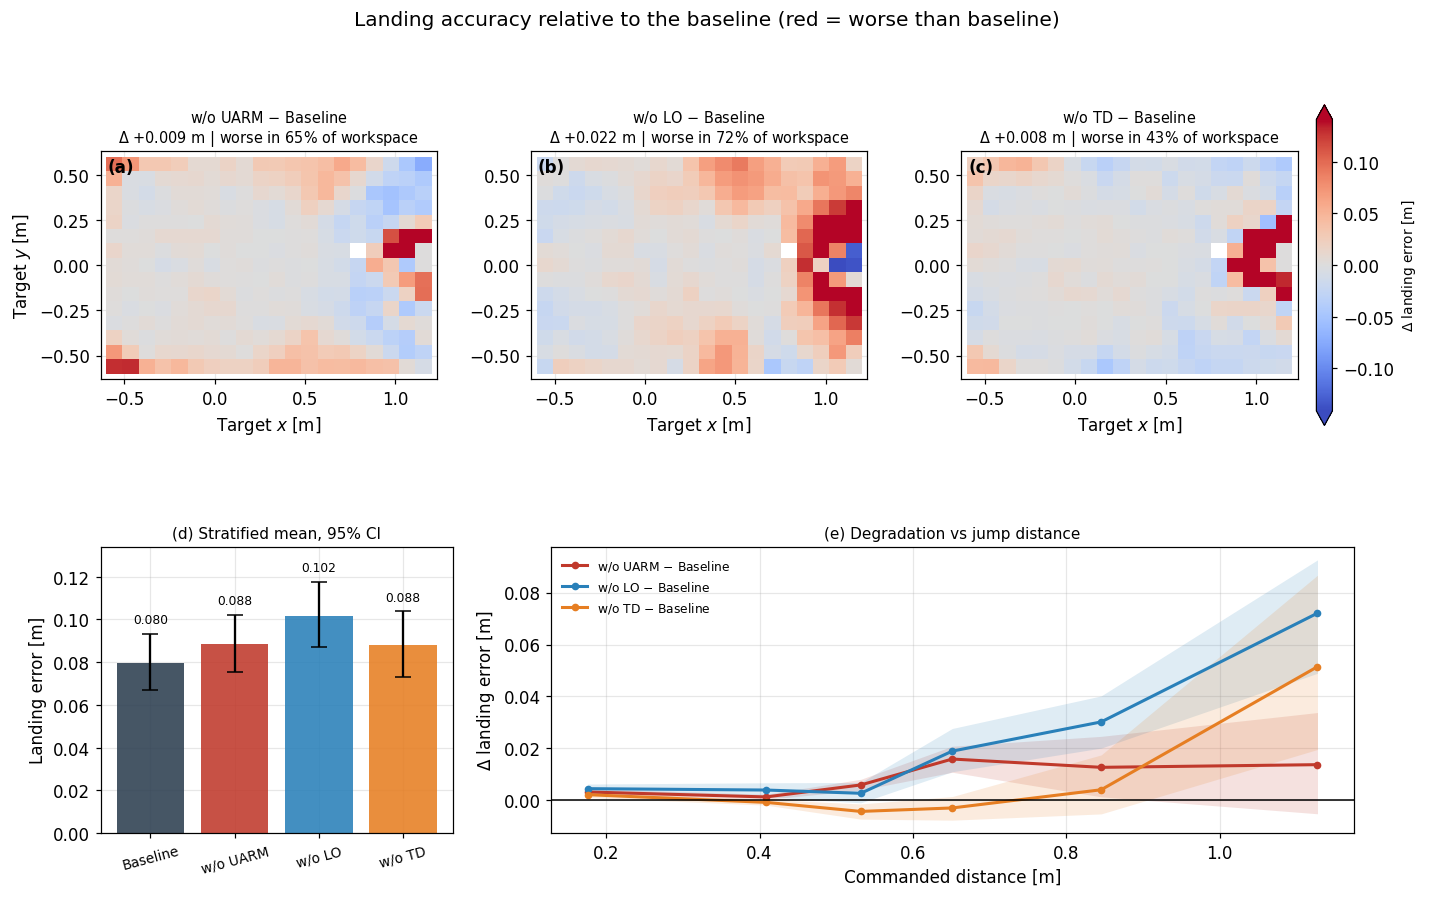

,Ablation,baseline,ablation,diff,ci_lo,ci_hi,rel,worse,p_holm,sig
0,w/o UARM,0.0797,0.0885,0.0087,0.0050,0.0129,10.9722,64.5485,0.0000,***
8,w/o LO,0.0797,0.1019,0.0221,0.0172,0.0273,27.7893,71.9064,0.0000,***
16,w/o TD,0.0797,0.0882,0.0084,0.0024,0.0156,10.6005,42.8094,0.1618,n.s.


In [6]:
attr = "pos_err_pen"
nA = len(abl)
fig = plt.figure(figsize=(4.9 * max(nA, 3), 8.6))
gs = fig.add_gridspec(2, max(nA, 3), height_ratios=[1.12, 1.0], hspace=0.40, wspace=0.28)
norm = shared_norm(attr)

top = []
for i, n in enumerate(abl):
    ax = fig.add_subplot(gs[0, i])
    top.append(ax)
    m = delta_map(ax, attr, n, norm)
    if i == 0:
        ax.set_ylabel("Target $y$ [m]")
    ax.text(0.02, 0.97, f"({chr(97+i)})", transform=ax.transAxes, va="top",
            fontsize=11, fontweight="bold")
cb = fig.colorbar(m, ax=top, pad=0.015, extend="both", fraction=0.03)
cb.set_label("$\\Delta$ landing error [m]", fontsize=9)

ax = fig.add_subplot(gs[1, 0])
bar_with_ci(ax, attr)
ax.set_ylabel("Landing error [m]")
ax.set_title(f"({chr(97+nA)}) Stratified mean, 95% CI", fontsize=10)

ax = fig.add_subplot(gs[1, 1:])
plot_radial_delta(ax, attr)
ax.set_ylabel("$\\Delta$ landing error [m]")
ax.set_title(f"({chr(98+nA)}) Degradation vs jump distance", fontsize=10)

fig.suptitle("Landing accuracy relative to the baseline (red = worse than baseline)", y=0.98)
savefig(fig, "fig1_landing")
plt.show()

COLS = ["Ablation", "baseline", "ablation", "diff", "ci_lo", "ci_hi", "rel", "worse",
        "p_holm", "sig"]
stats_df[stats_df["attr"] == attr][COLS].round(4)

## 5. Figure 2 — bounce at touchdown relative to the baseline

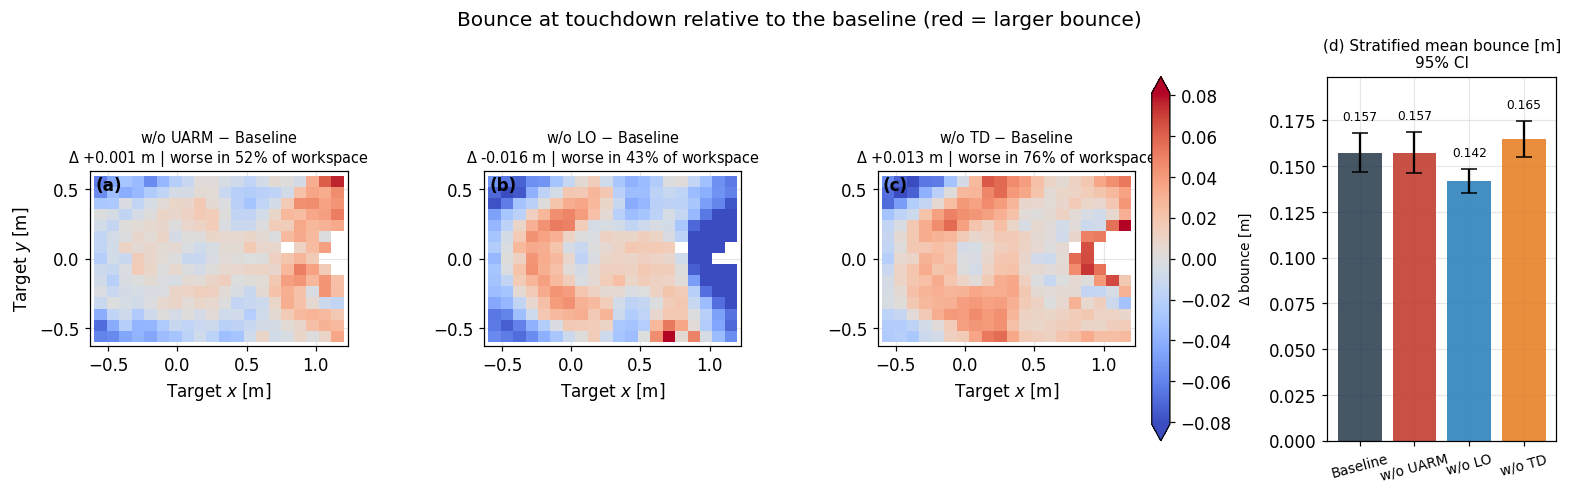

,Ablation,baseline,ablation,diff,ci_lo,ci_hi,rel,worse,p_holm,sig
2,w/o UARM,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,1.0000,n.s.
3,w/o UARM,0.1556,0.1563,0.0008,-0.0016,0.0032,0.4986,52.7211,1.0000,n.s.
10,w/o LO,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,1.0000,n.s.
11,w/o LO,0.1573,0.1408,-0.0164,-0.0219,-0.0113,-10.4418,43.9189,0.0001,***
18,w/o TD,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,1.0000,n.s.
19,w/o TD,0.1514,0.1649,0.0134,0.0104,0.0164,8.8534,78.5467,0.0000,***


In [7]:
if base.bounce is None:
    print("bounce_err.bin not found — skipping Figure 2")
else:
    attr = "bounce"
    fig = plt.figure(figsize=(4.4 * nA + 4.0, 4.3))
    gs = fig.add_gridspec(1, nA + 1, width_ratios=[1] * nA + [0.85], wspace=0.55)
    norm = shared_norm(attr)

    top = []
    for i, n in enumerate(abl):
        ax = fig.add_subplot(gs[0, i])
        top.append(ax)
        m = delta_map(ax, attr, n, norm)
        if i == 0:
            ax.set_ylabel("Target $y$ [m]")
        ax.text(0.02, 0.97, f"({chr(97+i)})", transform=ax.transAxes, va="top",
                fontsize=11, fontweight="bold")
    cb = fig.colorbar(m, ax=top, pad=0.015, extend="both", fraction=0.03)
    cb.set_label("$\\Delta$ bounce [m]", fontsize=9)

    ax = fig.add_subplot(gs[0, nA])
    bar_with_ci(ax, attr)
    ax.set_title(f"({chr(97+nA)}) Stratified mean bounce [m]\n95% CI", fontsize=10)

    fig.suptitle("Bounce at touchdown relative to the baseline (red = larger bounce)", y=1.02)
    savefig(fig, "fig2_bounce")
    plt.show()

    display(stats_df[stats_df["attr"].isin(["bounce", "invalid_td"])][COLS].round(4))

## 6. Figure 3 — lift-off state tracking

Left: each lift-off error component divided by the baseline value, so 1.0 is the baseline and the
four components are comparable despite having different units. Right: the per-cell difference
against the baseline for each component, for the policy set in `LO_MAP_POLICY`.

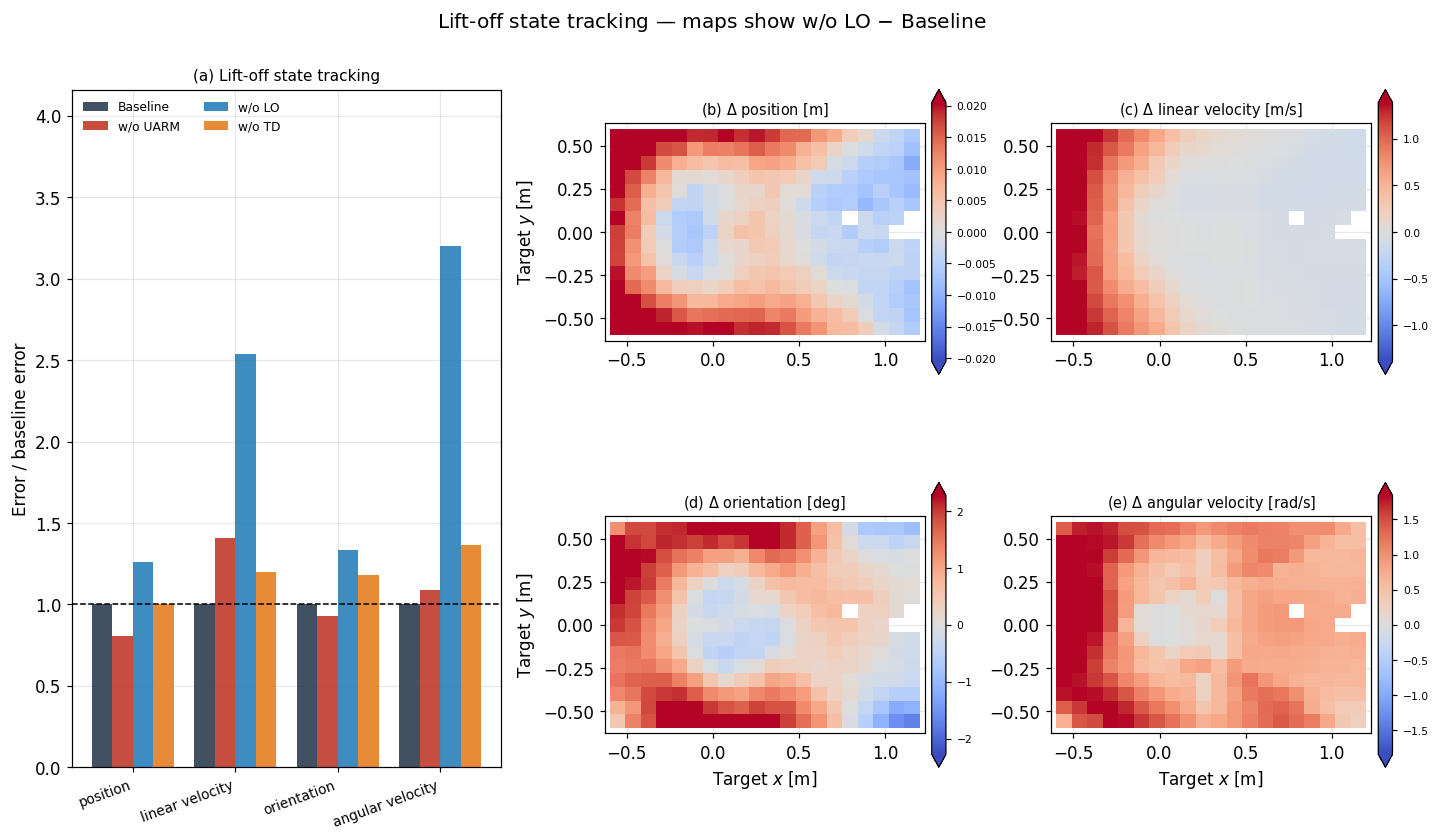

,Ablation,baseline,ablation,diff,ci_lo,ci_hi,rel,worse,p_holm,sig
4,w/o UARM,0.0206,0.0167,-0.0039,-0.0044,-0.0035,-18.9764,15.9864,0.0000,***
5,w/o UARM,0.1972,0.2779,0.0808,0.0674,0.0945,40.9646,61.5646,0.0000,***
6,w/o UARM,2.3017,2.1476,-0.1541,-0.2232,-0.0877,-6.6962,46.2585,0.0296,*
7,w/o UARM,0.4321,0.4712,0.0391,0.0152,0.0629,9.0392,57.4830,0.1198,n.s.
12,w/o LO,0.0208,0.0260,0.0053,0.0041,0.0064,25.3492,63.1757,0.0000,***
13,w/o LO,0.1979,0.5049,0.3071,0.2432,0.3733,155.1926,47.2973,0.0001,***
14,w/o LO,2.3028,3.0852,0.7825,0.6744,0.8910,33.9788,75.0000,0.0000,***
15,w/o LO,0.4316,1.3847,0.9531,0.8922,1.0154,220.8377,98.6486,0.0000,***
20,w/o TD,0.0202,0.0209,0.0007,0.0001,0.0012,3.2632,52.2491,0.2531,n.s.
21,w/o TD,0.1956,0.2373,0.0417,0.0349,0.0489,21.3411,85.4671,0.0000,***


In [8]:
lo_have = [a for a in LO_ATTRS if np.isfinite(CELL[a][BASELINE].values[valid_cells]).any()]
tgt = LO_MAP_POLICY if LO_MAP_POLICY in exps else abl[0]

if not lo_have:
    print("no lift-off files found — skipping Figure 3")
else:
    fig = plt.figure(figsize=(15.5, 8.0))
    gs = fig.add_gridspec(2, 3, width_ratios=[1.25, 1, 1], hspace=0.38, wspace=0.28)

    # (a) normalised components, all policies
    ax = fig.add_subplot(gs[:, 0])
    x = np.arange(len(lo_have))
    w = 0.8 / max(len(exps), 1)
    for i, (n, e) in enumerate(exps.items()):
        ax.bar(x + i * w - 0.4 + w / 2,
               [strat(a, n) / max(strat(a, BASELINE), 1e-12) for a in lo_have],
               width=w, color=e.color, alpha=0.9, label=e.label)
    ax.axhline(1.0, color="black", ls="--", lw=1)
    hi = max(strat(a, n) / max(strat(a, BASELINE), 1e-12) for a in lo_have for n in exps)
    ax.set_ylim(0, 1.30 * max(hi, 1.0))
    ax.set_xticks(x)
    ax.set_xticklabels([MNAME[a].replace("Lift-off ", "") for a in lo_have],
                       rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Error / baseline error")
    ax.set_title("(a) Lift-off state tracking", fontsize=10)
    ax.legend(fontsize=8, loc="upper left", ncol=2)

    # (b)-(e) per-component difference maps for one policy, each with its own scale
    slots = [gs[0, 1], gs[0, 2], gs[1, 1], gs[1, 2]]
    for k, (a, slot) in enumerate(zip(lo_have, slots)):
        ax = fig.add_subplot(slot)
        m = delta_map(ax, a, tgt, shared_norm(a), title=False)
        ax.set_title(f"({chr(98+k)}) $\\Delta$ {MNAME[a].replace('Lift-off ', '')} "
                     f"[{MUNIT[a]}]", fontsize=9.5)
        if k in (0, 2):
            ax.set_ylabel("Target $y$ [m]")
        if k in (0, 1):
            ax.set_xlabel("")
        cb = fig.colorbar(m, ax=ax, pad=0.02, extend="both", fraction=0.045)
        cb.ax.tick_params(labelsize=7)

    fig.suptitle(f"Lift-off state tracking — maps show {exps[tgt].label} $-$ Baseline", y=0.97)
    savefig(fig, "fig3_liftoff")
    plt.show()

    display(stats_df[stats_df["attr"].isin(lo_have)][COLS].round(4))

## 7. Figure 4 — landing error per target, with failures, next to the difference maps

Top row: mean landing error per grid cell for every policy, with the individual failed targets
overlaid as black crosses. Bottom row: the same difference maps as Figure 1, aligned under the
ablation they belong to, so the absolute performance and the change relative to the baseline can be
read off the same grid.

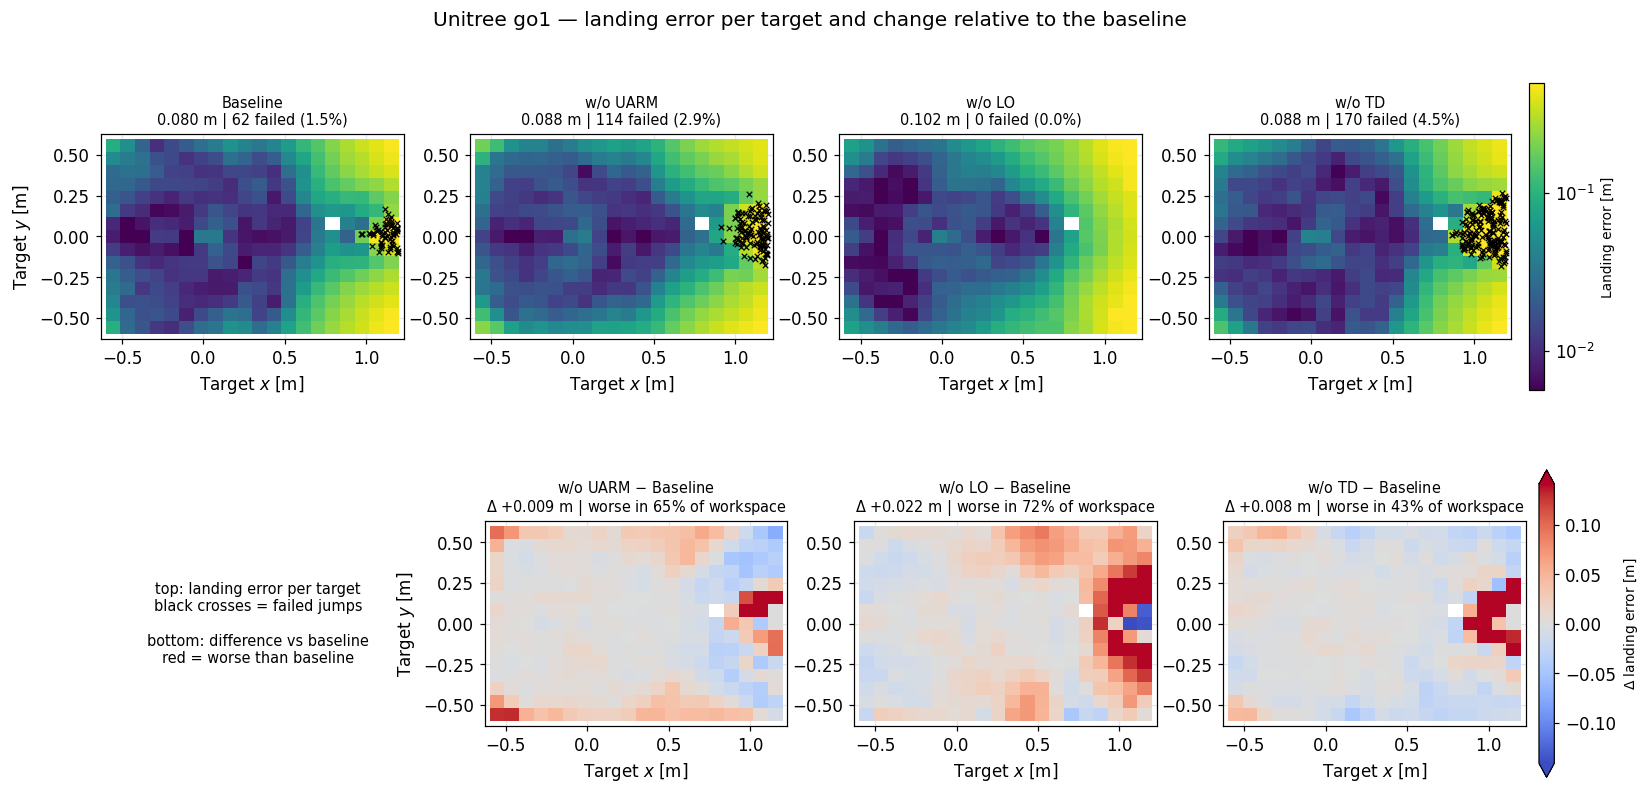

In [9]:
attr = "pos_err_pen"
ncol = len(exps)
fig = plt.figure(figsize=(4.3 * ncol, 8.2))
gs = fig.add_gridspec(2, ncol, height_ratios=[1.0, 1.0], hspace=0.26, wspace=0.22)

vals = np.concatenate([CELL[attr][n].values[valid_cells] for n in exps])
vmin = max(np.nanpercentile(vals, 2), 1e-3)
vmax = np.nanpercentile(vals, 99)
anorm = LogNorm(vmin=vmin, vmax=vmax)

row0 = []
for i, (n, e) in enumerate(exps.items()):
    ax = fig.add_subplot(gs[0, i])
    row0.append(ax)
    v = np.where(VALID, CELL[attr][n].values, np.nan)
    m0 = part.plot(ax, v, cmap="viridis", norm=anorm)
    ax.scatter(e.des_pos[e.fail, 0], e.des_pos[e.fail, 1], s=13, marker="x",
               color="black", lw=0.8, zorder=10)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
    ax.set_title(f"{e.label}\n{strat(attr, n):.3f} m | {int(e.fail.sum())} failed "
                 f"({strat('fail', n):.1f}%)", fontsize=9.5)
    ax.set_xlabel("Target $x$ [m]")
    if i == 0:
        ax.set_ylabel("Target $y$ [m]")
cb = fig.colorbar(m0, ax=row0, pad=0.012, fraction=0.026)
cb.set_label("Landing error [m]", fontsize=9)
cb.ax.minorticks_off()

norm = shared_norm(attr)
row1 = []
for i, n in enumerate(abl):
    ax = fig.add_subplot(gs[1, i + 1])
    row1.append(ax)
    m1 = delta_map(ax, attr, n, norm)
    if i == 0:
        ax.set_ylabel("Target $y$ [m]")
cb = fig.colorbar(m1, ax=row1, pad=0.012, extend="both", fraction=0.026)
cb.set_label("$\\Delta$ landing error [m]", fontsize=9)

ax = fig.add_subplot(gs[1, 0])
ax.axis("off")
ax.text(0.5, 0.5, "top: landing error per target\nblack crosses = failed jumps\n\n"
                  "bottom: difference vs baseline\nred = worse than baseline",
        ha="center", va="center", fontsize=9.5, transform=ax.transAxes)

fig.suptitle(f"Unitree {robot} — landing error per target and change relative to the baseline",
             y=0.96)
savefig(fig, "fig4_landing_per_target")
plt.show()

## 8. Table and draft text

In [10]:
stats_df.to_csv(osp.join(FIG_DIR, "ablation_cell_stats.csv"), index=False)
tex = summary.to_latex(index=False, float_format="%.3f", escape=False)
with open(osp.join(FIG_DIR, "ablation_table.tex"), "w") as fh:
    fh.write(tex)
print(tex)

\begin{tabular}{lrrrrrrrr}
\toprule
Policy & Landing error [m] & Failure rate [%] & Invalid touchdown rate [%] & Bounce distance [m] & Lift-off position [m] & Lift-off linear velocity [m/s] & Lift-off orientation [deg] & Lift-off angular velocity [rad/s] \\
\midrule
Baseline & 0.080 & 1.549 & 0.000 & 0.157 & 0.021 & 0.198 & 2.303 & 0.432 \\
w/o UARM & 0.088 & 2.872 & 0.000 & 0.157 & 0.017 & 0.279 & 2.145 & 0.470 \\
w/o LO & 0.102 & 0.000 & 0.000 & 0.142 & 0.026 & 0.502 & 3.076 & 1.381 \\
w/o TD & 0.088 & 4.459 & 0.000 & 0.165 & 0.021 & 0.237 & 2.724 & 0.588 \\
\bottomrule
\end{tabular}



In [11]:
def fp(p):
    return "< 0.001" if p < 1e-3 else f"= {p:.3f}"


def line(n, a):
    return (f"{MNAME[a]} {strat(a, BASELINE):.3f} -> {strat(a, n):.3f} {MUNIT[a]} "
            f"({S(n, a, 'rel'):+.0f}%, 95% CI [{S(n, a, 'ci_lo'):+.3f}, "
            f"{S(n, a, 'ci_hi'):+.3f}], p {fp(S(n, a, 'p_holm'))}, worse in "
            f"{S(n, a, 'worse'):.0f}% of the workspace)")


L = ["# Section 5.6 — ablation study (auto-generated draft)", ""]
L.append(f"Each policy was evaluated on an independently sampled random target set "
         f"({', '.join(f'{e.label}: {e.n}' for e in exps.values())} jumps). Because the target sets "
         f"differ, policies are compared over a shared {GRID_NX}x{GRID_NY} partition of the command "
         f"space ({int(VALID.sum())} usable cells); reported values are stratified over cells, "
         f"confidence intervals are cluster bootstraps over cells, and p-values are Wilcoxon "
         f"signed-rank over cells with Holm correction. Landing error is censored at {PEN_CAP} m "
         f"for failed jumps so that a failure-prone policy cannot appear accurate through "
         f"survivorship.")
L.append("")

if "no_uarm" in exps:
    n = "no_uarm"
    d = (CELL["pos_err_pen"][n].values - CELL["pos_err_pen"][BASELINE].values)[valid_cells]
    r = cdist[valid_cells]
    m = np.isfinite(d)
    rho = stats.spearmanr(r[m], d[m])
    near = r[m] < np.median(r[m])
    L.append("**UARM extension.** " + line(n, "pos_err_pen") + ", with the failure rate rising "
             f"from {strat('fail', BASELINE):.2f}% to {strat('fail', n):.2f}%. The degradation is "
             f"concentrated at long range ({d[m][near].mean():+.3f} m on near cells against "
             f"{d[m][~near].mean():+.3f} m on far cells, Spearman rho {rho.statistic:+.2f}, "
             f"p {fp(rho.pvalue)}), consistent with the pure-Bezier trajectory being unable to "
             f"charge for long jumps without violating the minimum-height constraint (Fig. 6).")
    L.append("")

n = "no_bounce_angular_touchdown"
if n in exps and exps[n].bounce is not None:
    L.append("**Touchdown penalties.** " + line(n, "bounce") + ". The invalid-touchdown rate rises "
             f"from {strat('invalid_td', BASELINE):.2f}% to {strat('invalid_td', n):.2f}% and the "
             f"failure rate from {strat('fail', BASELINE):.2f}% to {strat('fail', n):.2f}%. Since "
             f"no landing controller is used, this residual energy at touchdown cannot be "
             f"dissipated, so these are the landing conditions the penalty exists to avoid.")
    L.append("")

n = LO_MAP_POLICY
if n in exps:
    parts = [line(n, a) for a in lo_have]
    L.append("**Lift-off penalty.** Removing it degrades tracking of the commanded lift-off state: "
             + "; ".join(parts) + ". The achieved lift-off state therefore departs from the one the "
             "policy commanded, and since the ballistic relations of Section 5.2 are evaluated on "
             "the commanded state before the jump is executed, the physical interpretation of the "
             "action — the predicted apex and landing point — no longer describes the motion the "
             "robot performs.")
    L.append("")

L.append("*Caveats:* single training seed per condition, so the p-values quantify variation across "
         "the command space rather than across training runs; no landing controller is used, so the "
         "landing figures are a lower bound on achievable performance (cf. Section 5.3.1).")

report = "\n".join(L)
with open(osp.join(FIG_DIR, "section_5_6_draft.md"), "w") as fh:
    fh.write(report)
print(report)
print()
print("outputs in:", FIG_DIR)
for f in sorted(os.listdir(FIG_DIR)):
    print("  ", f)

# Section 5.6 — ablation study (auto-generated draft)

Each policy was evaluated on an independently sampled random target set (Baseline: 4096, w/o UARM: 4096, w/o LO: 4096, w/o TD: 4096 jumps). Because the target sets differ, policies are compared over a shared 20x15 partition of the command space (299 usable cells); reported values are stratified over cells, confidence intervals are cluster bootstraps over cells, and p-values are Wilcoxon signed-rank over cells with Holm correction. Landing error is censored at 0.5 m for failed jumps so that a failure-prone policy cannot appear accurate through survivorship.

**UARM extension.** Landing error 0.080 -> 0.088 m (+11%, 95% CI [+0.005, +0.013], p < 0.001, worse in 65% of the workspace), with the failure rate rising from 1.55% to 2.87%. The degradation is concentrated at long range (+0.003 m on near cells against +0.014 m on far cells, Spearman rho -0.02, p = 0.705), consistent with the pure-Bezier trajectory being unable to charge for lo